Environment ready!
NumPy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1


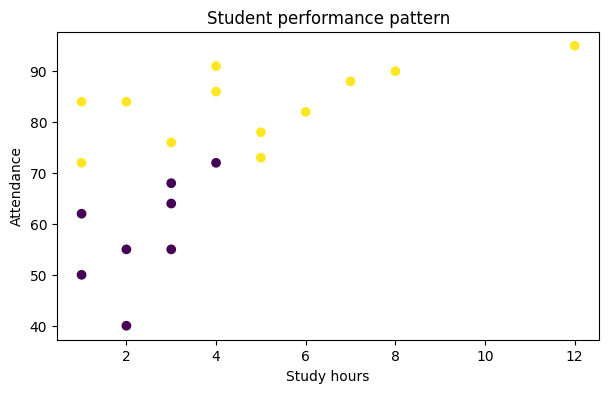

X shape: (20, 3)
y shape: (20,)
Training rows: 16
Testing rows : 4
Model trained!
Predictions:
[1 1 1 1]
    study_hours  attendance  assignments
16            1          62            4
7             1          50            3
12            7          88            9
15            1          84            8
Test accuracy:50.00%


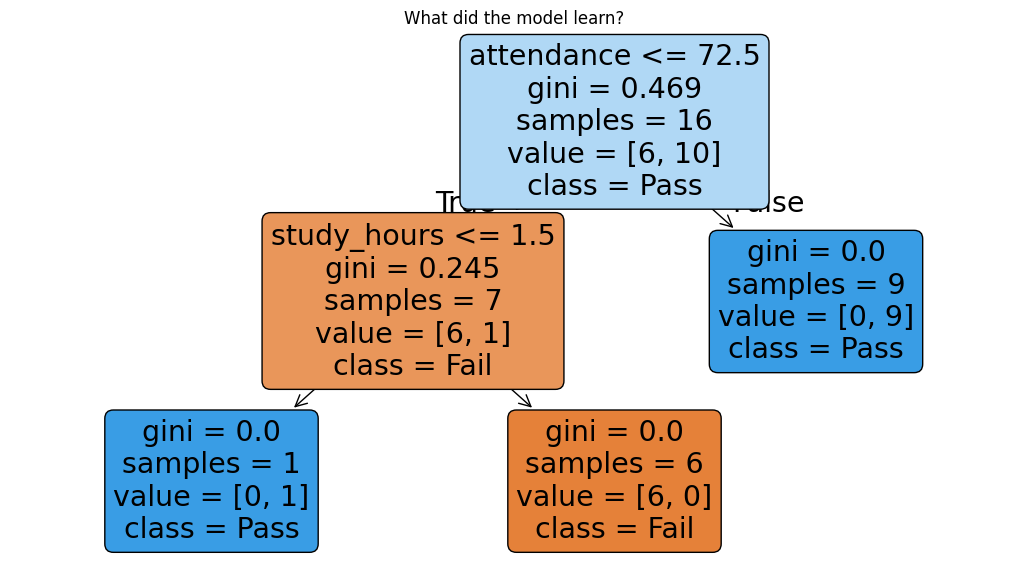

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)


df = pd.read_csv("student_performance.csv")
df.head()

df.groupby("result")[["study_hours","attendance","assignments"]].mean()
plt.figure(figsize=(7,4))
plt.scatter(df["study_hours"], df["attendance"], c=df["result"])
plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student performance pattern")
plt.show()



X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]



print("X shape:", X.shape)
print("y shape:", y.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")
predictions = model.predict(X_test)
print("Predictions:")
print(predictions)
print(X_test)
accuracy = accuracy_score(y_test , predictions)
print(f"Test accuracy:{accuracy:.2%}")
plt.figure(figsize=(13,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("What did the model learn?")
plt.show()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.image as mpimg

plt.rcParams["figure.figsize"] = (8, 6)

# Google Colab file location
DATA_DIR = Path("/content")

tif_files = list(DATA_DIR.glob("*.tif"))

print("TIFF files found:")
for f in tif_files:
    print(" ", f.name)

print("Total TIFF files:", len(tif_files))

TIFF files found:
  BAND2.tif
  BAND4.tif
  BAND3.tif
  BAND5.tif
Total TIFF files: 4


In [5]:
for i, f in enumerate(tif_files):
    print(i, f)

0 /content/BAND2.tif
1 /content/BAND4.tif
2 /content/BAND3.tif
3 /content/BAND5.tif


In [6]:
print(tif_files[0])
print(tif_files[1])
print(tif_files[2])
print(tif_files[3])

/content/BAND2.tif
/content/BAND4.tif
/content/BAND3.tif
/content/BAND5.tif


In [7]:
from pathlib import Path

tif_files = [
    Path("/content/BAND2.tif"),
    Path("/content/BAND3.tif"),
    Path("/content/BAND4.tif"),
    Path("/content/BAND5.tif")
]

print("TIFF files in correct order:")
for i, f in enumerate(tif_files):
    print(i, f)

TIFF files in correct order:
0 /content/BAND2.tif
1 /content/BAND3.tif
2 /content/BAND4.tif
3 /content/BAND5.tif


In [8]:
# 1. Read each of the 4 files directly
b1 = mpimg.imread(tif_files[0])
b2 = mpimg.imread(tif_files[1])
b3 = mpimg.imread(tif_files[2])
b4 = mpimg.imread(tif_files[3])

# 2. Convert integer values to floating point numbers for calculations
b1 = b1.astype(np.float32)
b2 = b2.astype(np.float32)
b3 = b3.astype(np.float32)
b4 = b4.astype(np.float32)

# 3. Store them in a list
bands = [b1, b2, b3, b4]

# 4. Print the shape (dimensions) of each band
print("Band 1 Shape:", b1.shape)
print("Band 2 Shape:", b2.shape)
print("Band 3 Shape:", b3.shape)
print("Band 4 Shape:", b4.shape)

Band 1 Shape: (7113, 7744)
Band 2 Shape: (7113, 7744)
Band 3 Shape: (7113, 7744)
Band 4 Shape: (7113, 7744)


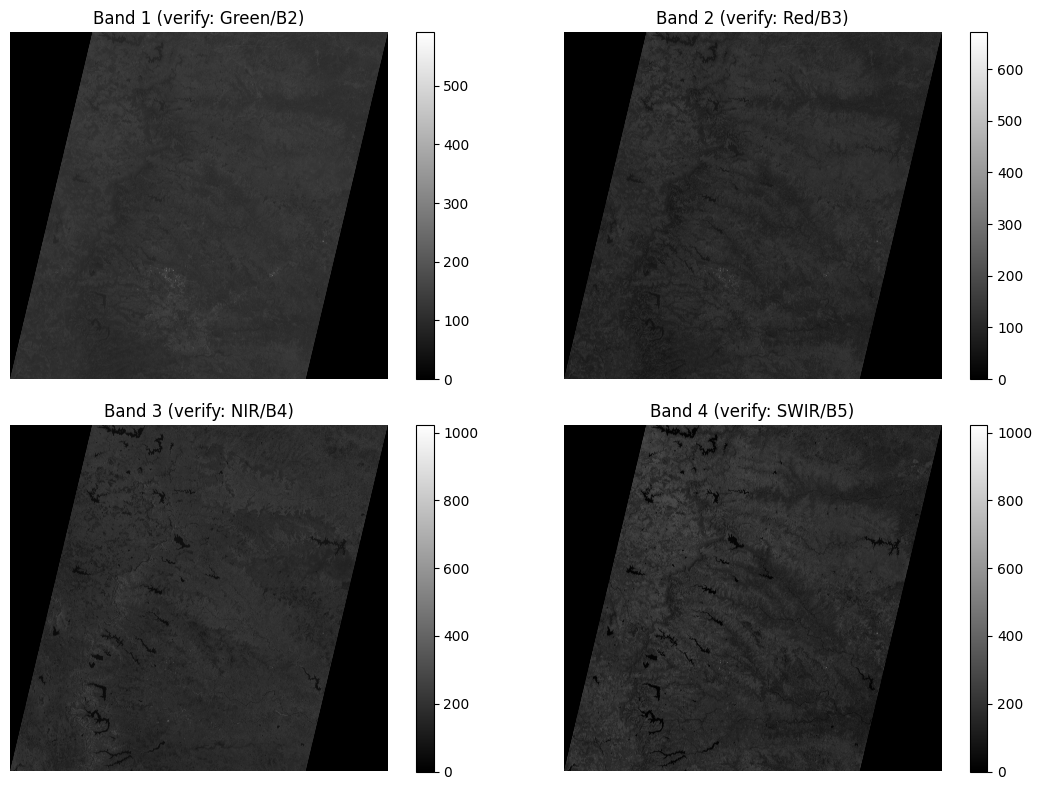

In [9]:
if len(tif_files) >= 4:
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    names = ["Band 1 (verify: Green/B2)", "Band 2 (verify: Red/B3)",
             "Band 3 (verify: NIR/B4)", "Band 4 (verify: SWIR/B5)"]
    for a, b, name in zip(ax.ravel(), bands, names):
        im = a.imshow(b, cmap="gray")
        a.set_title(name)
        a.axis("off")
        plt.colorbar(im, ax=a, fraction=0.046)
    plt.tight_layout()

In [10]:
if len(tif_files) >= 4:
    for i,b in enumerate(bands,1):
        print(f"Band {i}: shape={b.shape}, min={np.nanmin(b):.2f}, max={np.nanmax(b):.2f}, mean={np.nanmean(b):.2f}")

Band 1: shape=(7113, 7744), min=0.00, max=591.00, mean=92.77
Band 2: shape=(7113, 7744), min=0.00, max=671.00, mean=85.99
Band 3: shape=(7113, 7744), min=0.00, max=1023.00, mean=139.82
Band 4: shape=(7113, 7744), min=0.00, max=1023.00, mean=136.60


In [12]:
if len(tif_files) >= 4:
    G, R, NIR, SWIR = bands
    eps = 1e-6
    ndvi = (NIR - R) / (NIR + R + eps)
    rows, cols = np.indices(G.shape)
    sample = pd.DataFrame({
        "row": rows.ravel(),
        "col": cols.ravel(),
        "green": G.ravel(),
        "red": R.ravel(),
        "nir": NIR.ravel(),
        "swir": SWIR.ravel(),
        "ndvi": ndvi.ravel()
    })
    sample = sample.replace([np.inf, -np.inf], np.nan).dropna()
    print(sample.head())
    print("Number of valid pixels:", len(sample))

   row  col  green  red  nir  swir  ndvi
0    0    0    0.0  0.0  0.0   0.0   0.0
1    0    1    0.0  0.0  0.0   0.0   0.0
2    0    2    0.0  0.0  0.0   0.0   0.0
3    0    3    0.0  0.0  0.0   0.0   0.0
4    0    4    0.0  0.0  0.0   0.0   0.0
Number of valid pixels: 55083072


In [ ]:
# Teaching labels. Thresholds are deliberately exposed so students can experiment.
if len(tif_files) >= 4:
    brightness = (G + R + NIR + SWIR) / 4.0

    # These are illustrative rules, not scientific land-cover classification.
    y = np.full(len(sample), -1, dtype=int)
    s_ndvi = sample["ndvi"].to_numpy()
    s_red = sample["red"].to_numpy()
    s_nir = sample["nir"].to_numpy()

    # 0 = water-like, 1 = vegetation-like, 2 = other
    water = (s_ndvi < 0.0) & (s_nir < np.nanpercentile(s_nir, 45))
    veg = (s_ndvi > 0.35)
    other = ~(water | veg)

    y[water] = 0
    y[veg] = 1
    y[other] = 2
    sample["label"] = y

    print(sample["label"].value_counts().sort_index())

In [ ]:
def fit_nearest_centroid(X, y):
    classes = np.unique(y)
    centroids = {}
    for c in classes:
        centroids[c] = X[y == c].mean(axis=0)
    return centroids

def predict_nearest_centroid(X, centroids):
    classes = sorted(centroids.keys())
    C = np.vstack([centroids[c] for c in classes])
    # squared Euclidean distance: samples x classes
    d2 = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
    return np.array([classes[i] for i in np.argmin(d2, axis=1)])

features = ["green","red","nir","swir"]
work = sample[sample["label"] >= 0].copy()

# Simple reproducible split
rng = np.random.default_rng(42)
idx = rng.permutation(len(work))
cut = int(0.7 * len(work))
train = work.iloc[idx[:cut]]
test  = work.iloc[idx[cut:]]

# Standardise using training statistics so one band does not dominate by scale.
mu = train[features].mean().to_numpy()
sigma = train[features].std().to_numpy() + 1e-8

X_train = (train[features].to_numpy() - mu) / sigma
X_test  = (test[features].to_numpy() - mu) / sigma

centroids = fit_nearest_centroid(X_train, train["label"].to_numpy())
pred = predict_nearest_centroid(X_test, centroids)

accuracy = np.mean(pred == test["label"].to_numpy())
print("Simple hold-out accuracy:", round(accuracy, 3))
print("Centroids:")
for c,v in centroids.items():
    print(c, np.round(v,2))

In [ ]:
# Confusion matrix with NumPy only
classes = sorted(centroids.keys())
cm = np.zeros((len(classes), len(classes)), dtype=int)
for actual, predicted in zip(test["label"], pred):
    cm[int(actual), int(predicted)] += 1

print("Rows = actual, columns = predicted")
print(pd.DataFrame(cm, index=classes, columns=classes))

In [ ]:
if len(tif_files) >= 4:
    # Downsample for speed on low-end laptops.
    step = max(1, int(max(G.shape) / 700))
    Gs, Rs, Ns, Ss = G[::step,::step], R[::step,::step], NIR[::step,::step], SWIR[::step,::step]
    flat = np.column_stack([Gs.ravel(), Rs.ravel(), Ns.ravel(), Ss.ravel()])
    valid = np.isfinite(flat).all(axis=1)
    Z = np.zeros(len(flat), dtype=int)
    Z[:] = -1
    Z[valid] = predict_nearest_centroid((flat[valid]-mu)/sigma, centroids)
    classified = Z.reshape(Gs.shape)

    plt.figure(figsize=(10,7))
    plt.imshow(classified, cmap="viridis", vmin=min(classes), vmax=max(classes))
    plt.title("Teaching classification map: 0=water-like, 1=vegetation-like, 2=other")
    plt.axis("off")
    plt.colorbar()
    plt.show()

In [ ]:
def kmeans_numpy(X, k=3, iterations=12, seed=7):
    rng = np.random.default_rng(seed)
    start = rng.choice(len(X), size=k, replace=False)
    centers = X[start].copy()

    for it in range(iterations):
        d2 = ((X[:, None, :] - centers[None, :, :])**2).sum(axis=2)
        labels = np.argmin(d2, axis=1)

        new_centers = centers.copy()
        for j in range(k):
            if np.any(labels == j):
                new_centers[j] = X[labels == j].mean(axis=0)

        movement = np.sqrt(((new_centers-centers)**2).sum())
        centers = new_centers
        print(f"iteration {it+1:02d} | center movement = {movement:.4f}")

        if movement < 1e-4:
            break
    return labels, centers

# Use a small random sample to keep laptops responsive.
if len(tif_files) >= 4:
    X_all = sample[features].to_numpy()
    Xn = (X_all - X_all.mean(axis=0)) / (X_all.std(axis=0)+1e-8)
    take = min(12000, len(Xn))
    ix = np.random.default_rng(3).choice(len(Xn), take, replace=False)
    cluster_labels, cluster_centers = kmeans_numpy(Xn[ix], k=3)
    print("Cluster centres:\n", np.round(cluster_centers,2))

In [ ]:
# Build a small RL grid from NDVI.
# This uses only NumPy and Matplotlib.
if len(tif_files) >= 4:
    step = max(1, int(max(NIR.shape) / 80))
    small_ndvi = ((NIR - R) / (NIR + R + 1e-6))[::step, ::step]
    small_ndvi = np.nan_to_num(small_ndvi, nan=0.0, posinf=0.0, neginf=0.0)
    # Keep a manageable 40x40-ish world.
    h,w = small_ndvi.shape
    h2,w2 = min(h,40), min(w,40)
    nd = small_ndvi[:h2,:w2]

    # Reward: positive when entering a higher-NDVI cell.
    def reward(r,c,old_r,old_c):
        return float(nd[r,c] - nd[old_r,old_c])

    actions = [(-1,0),(1,0),(0,-1),(0,1)]
    Q = np.zeros((h2,w2,4), dtype=np.float32)

    alpha = 0.2
    gamma = 0.9
    epsilon = 0.25
    rng = np.random.default_rng(5)

    for episode in range(500):
        r,c = rng.integers(h2), rng.integers(w2)
        for t in range(80):
            if rng.random() < epsilon:
                a = rng.integers(4)
            else:
                a = np.argmax(Q[r,c])

            dr,dc = actions[a]
            nr = int(np.clip(r+dr,0,h2-1))
            nc = int(np.clip(c+dc,0,w2-1))
            rew = reward(nr,nc,r,c)

            Q[r,c,a] += alpha * (rew + gamma*np.max(Q[nr,nc]) - Q[r,c,a])
            r,c = nr,nc

    # Greedy trajectory
    r,c = h2//2, w2//2
    path = [(r,c)]
    for _ in range(100):
        a = np.argmax(Q[r,c])
        dr,dc = actions[a]
        r = int(np.clip(r+dr,0,h2-1))
        c = int(np.clip(c+dc,0,w2-1))
        path.append((r,c))

    rr,cc = zip(*path)
    plt.figure(figsize=(9,7))
    plt.imshow(nd, cmap="gray")
    plt.plot(cc, rr, marker="o", markersize=2)
    plt.title("Educational RL explorer: trajectory shaped by NDVI reward")
    plt.axis("off")
    plt.show()